https://www.kaggle.com/datasets/yusufmurtaza01/tomato-leaf-disease

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import os

from PIL import Image

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary

try :
    import torch_directml
    device = torch_directml.device(0) 
except:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(device)

privateuseone:0


In [3]:
image_path = []
labels = []

for label in os.listdir('img'):   
    for image in os.listdir(f'img/{label}'):
        image_path.append(f'img/{label}/{image}')
        labels.append(label)

df = pd.DataFrame(zip(image_path, labels), columns=['image_path', 'labels'])

print(df['labels'].unique())
display(df.head())

<StringArray>
['butterfly',       'cat',   'chicken',       'cow',       'dog',  'elephant',
     'horse',     'sheep',    'spider',  'squirrel']
Length: 10, dtype: str


,image_path,labels
0,img/butterfly/e030b20928e90021d85a5854ee454296...,butterfly
1,img/butterfly/e030b20929e90021d85a5854ee454296...,butterfly
2,img/butterfly/e030b2092be90021d85a5854ee454296...,butterfly
3,img/butterfly/e030b2092ce90021d85a5854ee454296...,butterfly
4,img/butterfly/e030b2092de90021d85a5854ee454296...,butterfly


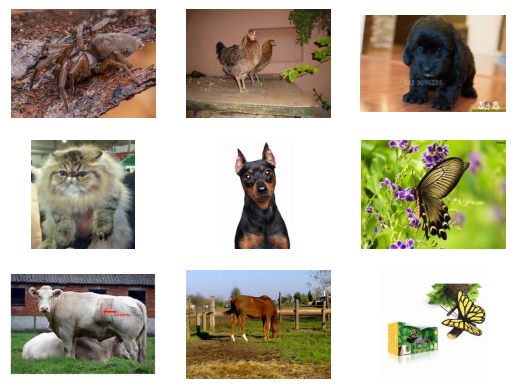

In [21]:
n_rows = 3
n_cols = 3

fig, ax = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
    for col in range(n_cols):
        image = Image.open(df.sample(n=1)['image_path'].iloc[0]).convert('RGB')
        ax[row, col].imshow(image)
        ax[row, col].axis('off')

plt.show()

In [5]:
train_df, test_df = train_test_split(df, test_size=0.3, random_state=0)
test_df, val_df = train_test_split(test_df, test_size=0.5, random_state=0)

print(f'Train dataset shape : {train_df.shape}')
print(f'Validation dataset shape : {val_df.shape}')
print(f'Test dataset shape : {test_df.shape}')

Train dataset shape : (18325, 2)
Validation dataset shape : (3927, 2)
Test dataset shape : (3927, 2)


In [6]:
label_encoder = LabelEncoder()
label_encoder.fit(df['labels'])

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
])

In [7]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform = None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

    def __len__(self):
        return self.dataframe.shape[0]
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image).to(device)

        return image, label

In [8]:
train_dataset = CustomImageDataset(dataframe= train_df, transform= transform)
val_dataset = CustomImageDataset(dataframe= val_df, transform= transform)
test_dataset = CustomImageDataset(dataframe= test_df, transform= transform)

In [9]:
LR = 1e-4
BATCH_SIZE = 64
EPOCHS = 12

In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [11]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pooling = nn.MaxPool2d(2,2)

        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()
        self.linear = nn.Linear((128*16*16), 128) 

        self.output = nn.Linear(128, len(df['labels'].unique()))

    def forward(self, x):
        x = self.conv1(x) 
        x = self.pooling(x)
        x = self.relu(x)

        x = self.conv2(x) 
        x = self.pooling(x) 
        x = self.relu(x)

        x = self.conv3(x) 
        x = self.pooling(x)
        x = self.relu(x)

        x = self.flatten(x)
        x = self.linear(x)
        x = self.output(x)
        return x

In [12]:
model = Net().to(device)

In [13]:
try:
    summary(model, input_size = (3, 128, 128))
except:
    pass

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)

In [15]:
total_loss_train_plot = []
total_acc_train_plot = []
total_loss_val_plot = []
total_acc_val_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_loss_val = 0
    total_acc_val = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(inputs)
        train_loss = criterion(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()

        train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
        total_acc_train += train_acc

        optimizer.step()

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            val_loss = criterion(outputs, labels)
            total_loss_val += val_loss.item()

            val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
            total_acc_val += val_acc

    len_train = len(train_dataset)
    len_val = len(val_dataset)

    total_loss_train_plot.append(round(total_loss_train/len_train, 4))
    total_loss_val_plot.append(round(total_loss_val/len_val, 4))  

    total_acc_train_plot.append(round((total_acc_train / len_train) * 100, 4))
    total_acc_val_plot.append(round((total_acc_val / len_val) * 100, 4))  
    
    print('='*25)
    print(f''' Epoch: {epoch+1}/{EPOCHS}, 
    Train Loss: {round(total_loss_train / len_train, 4)}, Train Accuracy: {round((total_acc_train / len_train) * 100, 4)}%
    Validation Loss: {round(total_loss_val / len_val, 4)}, Validation Accuracy: {round((total_acc_val / len_val) * 100, 4)}%
    ''')

c:\Users\Flo pro\Documents\Portfolio\env\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


 Epoch: 1/12, 
    Train Loss: 0.0298, Train Accuracy: 32.5348%
    Validation Loss: 0.0257, Validation Accuracy: 43.4938%
    
 Epoch: 2/12, 
    Train Loss: 0.0246, Train Accuracy: 46.2156%
    Validation Loss: 0.0241, Validation Accuracy: 47.3899%
    
 Epoch: 3/12, 
    Train Loss: 0.0218, Train Accuracy: 52.6221%
    Validation Loss: 0.0213, Validation Accuracy: 54.7237%
    
 Epoch: 4/12, 
    Train Loss: 0.0196, Train Accuracy: 58.0737%
    Validation Loss: 0.0201, Validation Accuracy: 57.2447%
    
 Epoch: 5/12, 
    Train Loss: 0.018, Train Accuracy: 61.3424%
    Validation Loss: 0.0203, Validation Accuracy: 56.3535%
    
 Epoch: 6/12, 
    Train Loss: 0.0168, Train Accuracy: 64.3547%
    Validation Loss: 0.02, Validation Accuracy: 57.8559%
    
 Epoch: 7/12, 
    Train Loss: 0.0157, Train Accuracy: 66.7394%
    Validation Loss: 0.0182, Validation Accuracy: 62.1085%
    
 Epoch: 8/12, 
    Train Loss: 0.0146, Train Accuracy: 68.8513%
    Validation Loss: 0.0179, Validation Acc

In [16]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0

    for inputs, labels in test_loader:
        predictions = model(inputs)

        test_loss = criterion(predictions, labels)
        total_loss_test += test_loss.item()

        total_acc_test += (torch.argmax(predictions, axis=1) == labels).sum().item()

        len_test = len(test_dataset)   
        avg_loss_test = total_loss_test / len_test
        avg_acc_test = (total_acc_test / len_test) * 100

    print(f'''Test Loss: {round(avg_loss_test, 4)}, Test Accuracy: {round(avg_acc_test, 4)}%''')

Test Loss: 0.0176, Test Accuracy: 64.5531%


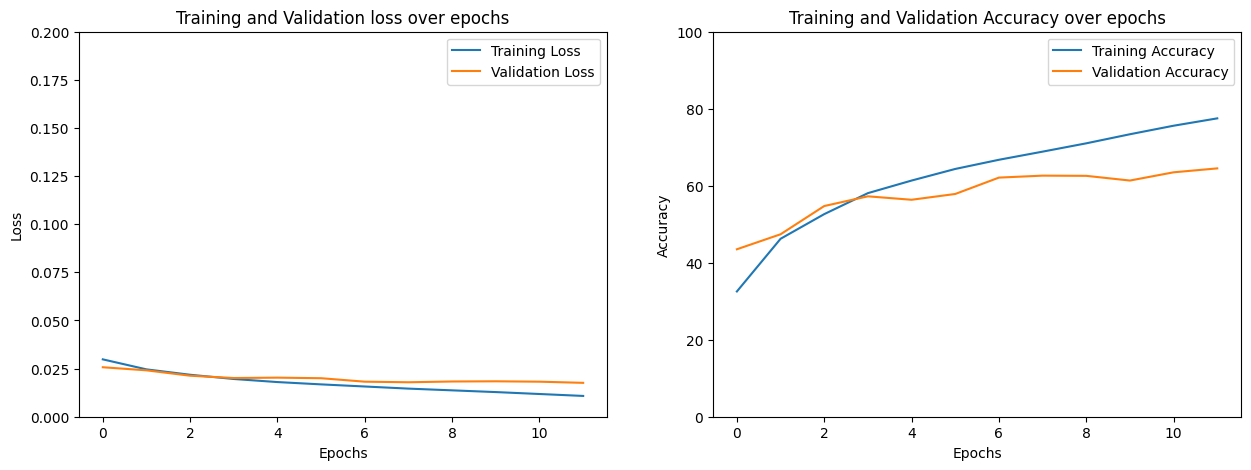

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

ax[0].plot(total_loss_train_plot, label='Training Loss')
ax[0].plot(total_loss_val_plot, label='Validation Loss')
ax[0].set_title('Training and Validation loss over epochs')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_ylim([0, 0.2])
ax[0].legend()

ax[1].plot(total_acc_train_plot, label='Training Accuracy')
ax[1].plot(total_acc_val_plot, label='Validation Accuracy')
ax[1].set_title('Training and Validation Accuracy over epochs')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim([0, 100])
ax[1].legend()

plt.show()

In [22]:
def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image = transform(image).to(device)

    output = model(image.unsqueeze(0))
    output = torch.argmax(output, axis=1).item()

    return label_encoder.inverse_transform([output])

predict_image('spider_img.jpg')

array(['spider'], dtype=object)

# Modèle pré-entraîné

In [108]:
from torchvision import models

In [109]:
model = models.googlenet(weights='DEFAULT')

In [110]:
for param in model.parameters():
    param.requires_grad = True

In [111]:
model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [112]:
num_classes = len(train_df['labels'].unique())

In [113]:
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model.fc

Linear(in_features=1024, out_features=10, bias=True)

In [122]:
model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [123]:
LR = 1e-3
BATCH_SIZE = 32
EPOCHS = 10

In [124]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [125]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)

In [126]:
total_loss_train_plot = []
total_acc_train_plot = []
total_loss_val_plot = []
total_acc_val_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_loss_val = 0
    total_acc_val = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(inputs)
        train_loss = criterion(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()

        train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
        total_acc_train += train_acc

        optimizer.step()

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            val_loss = criterion(outputs, labels)
            total_loss_val += val_loss.item()

            val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
            total_acc_val += val_acc

    len_train = len(train_dataset)
    len_val = len(val_dataset)

    total_loss_train_plot.append(round(total_loss_train/len_train, 4))
    total_loss_val_plot.append(round(total_loss_val/len_val, 4))  

    total_acc_train_plot.append(round((total_acc_train / len_train) * 100, 4))
    total_acc_val_plot.append(round((total_acc_val / len_val) * 100, 4))  
    
    print('='*25)
    print(f''' Epoch: {epoch+1}/{EPOCHS}, 
    Train Loss: {round(total_loss_train / len_train, 4)}, Train Accuracy: {round((total_acc_train / len_train) * 100, 4)}%
    Validation Loss: {round(total_loss_val / len_val, 4)}, Validation Accuracy: {round((total_acc_val / len_val) * 100, 4)}%
    ''')

 Epoch: 1/10, 
    Train Loss: 0.0075, Train Accuracy: 92.0437%
    Validation Loss: 0.0143, Validation Accuracy: 86.631%
    
 Epoch: 2/10, 
    Train Loss: 0.0055, Train Accuracy: 94.2538%
    Validation Loss: 0.016, Validation Accuracy: 85.9689%
    
 Epoch: 3/10, 
    Train Loss: 0.0043, Train Accuracy: 95.5362%
    Validation Loss: 0.0149, Validation Accuracy: 87.1403%
    
 Epoch: 4/10, 
    Train Loss: 0.0044, Train Accuracy: 95.3997%
    Validation Loss: 0.0152, Validation Accuracy: 86.8857%
    
 Epoch: 5/10, 
    Train Loss: 0.0036, Train Accuracy: 96.1855%
    Validation Loss: 0.0149, Validation Accuracy: 87.726%
    
 Epoch: 6/10, 
    Train Loss: 0.0029, Train Accuracy: 96.9441%
    Validation Loss: 0.0149, Validation Accuracy: 88.5409%
    
 Epoch: 7/10, 
    Train Loss: 0.0034, Train Accuracy: 96.4584%
    Validation Loss: 0.0157, Validation Accuracy: 87.0894%
    
 Epoch: 8/10, 
    Train Loss: 0.0027, Train Accuracy: 97.1405%
    Validation Loss: 0.0157, Validation Acc

In [127]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0

    for inputs, labels in test_loader:
        predictions = model(inputs)

        test_loss = criterion(predictions, labels)
        total_loss_test += test_loss.item()

        total_acc_test += (torch.argmax(predictions, axis=1) == labels).sum().item()

        len_test = len(test_dataset)   
        avg_loss_test = total_loss_test / len_test
        avg_acc_test = (total_acc_test / len_test) * 100

    print(f'''Test Loss: {round(avg_loss_test, 4)}, Test Accuracy: {round(avg_acc_test, 4)}%''')

Test Loss: 0.0171, Test Accuracy: 87.1658%


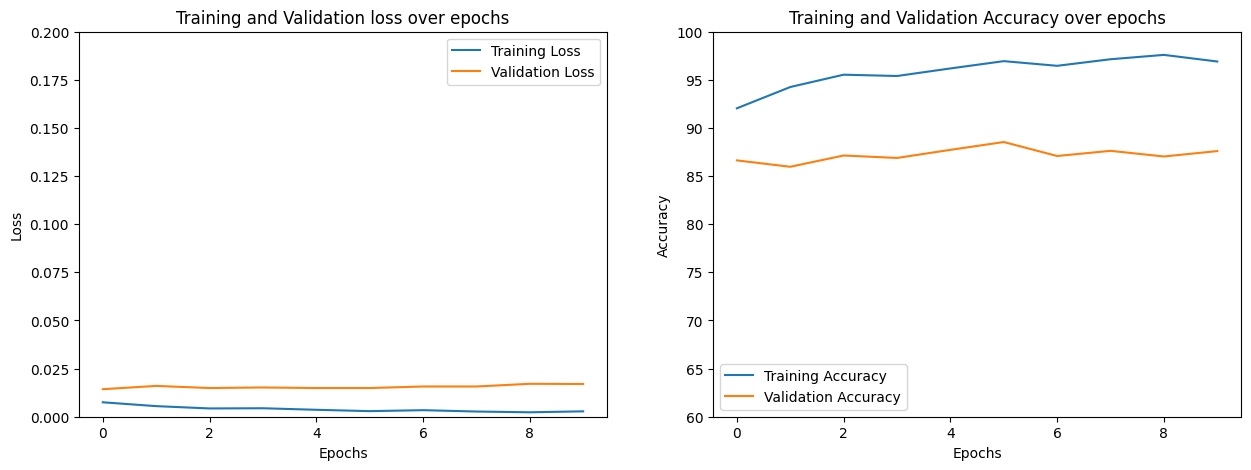

In [128]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

ax[0].plot(total_loss_train_plot, label='Training Loss')
ax[0].plot(total_loss_val_plot, label='Validation Loss')
ax[0].set_title('Training and Validation loss over epochs')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_ylim([0, 0.2])
ax[0].legend()

ax[1].plot(total_acc_train_plot, label='Training Accuracy')
ax[1].plot(total_acc_val_plot, label='Validation Accuracy')
ax[1].set_title('Training and Validation Accuracy over epochs')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim([60, 100])
ax[1].legend()

plt.show()